<a href="https://colab.research.google.com/github/Dockby/Government-Type-Economic-Impact/blob/main/Government_Type_Economic_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [38]:
df=pd.read_csv('/content/world-data-2023.csv')
print("Shape:", df.shape)
print()

for col in df.columns:
    print(col)


Shape: (195, 35)

Country
Density
(P/Km2)
Abbreviation
Agricultural Land( %)
Land Area(Km2)
Armed Forces size
Birth Rate
Calling Code
Capital/Major City
Co2-Emissions
CPI
CPI Change (%)
Currency-Code
Fertility Rate
Forested Area (%)
Gasoline Price
GDP
Gross primary education enrollment (%)
Gross tertiary education enrollment (%)
Infant mortality
Largest city
Life expectancy
Maternal mortality ratio
Minimum wage
Official language
Out of pocket health expenditure
Physicians per thousand
Population
Population: Labor force participation (%)
Tax revenue (%)
Total tax rate
Unemployment rate
Urban_population
Latitude
Longitude


In [39]:
# Keep only useful columns
cols = ['Country', 'GDP', 'Total tax rate',
        'Unemployment rate', 'Tax revenue (%)']

df = df[cols].copy()



In [40]:

for col in ['Total tax rate', 'Unemployment rate', 'Tax revenue (%)']:
    df[col] = df[col].str.replace('%', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[['Total tax rate', 'Unemployment rate', 'Tax revenue (%)']].head())

   Total tax rate  Unemployment rate  Tax revenue (%)
0            71.4              11.12              9.3
1            36.6              12.33             18.6
2            66.1              11.70             37.2
3             NaN                NaN              NaN
4            49.1               6.89              9.2


In [41]:
govt_map = {
    # Democracy
    'United States':'Democracy', 'India':'Democracy', 'Germany':'Democracy',
    'France':'Democracy', 'Brazil':'Democracy', 'Japan':'Democracy',
    'United Kingdom':'Democracy', 'Canada':'Democracy', 'Australia':'Democracy',
    'South Africa':'Democracy', 'Mexico':'Democracy', 'Argentina':'Democracy',
    'Indonesia':'Democracy', 'South Korea':'Democracy', 'Nigeria':'Democracy',
    'Colombia':'Democracy', 'Chile':'Democracy', 'Poland':'Democracy',
    'Sweden':'Democracy', 'Netherlands':'Democracy',

    # Autocracy
    'Russia':'Autocracy', 'Saudi Arabia':'Autocracy', 'Turkey':'Autocracy',
    'Egypt':'Autocracy', 'Pakistan':'Autocracy', 'Iran':'Autocracy',
    'United Arab Emirates':'Autocracy', 'Hungary':'Autocracy',
    'Algeria':'Autocracy', 'Kazakhstan':'Autocracy', 'Venezuela':'Autocracy',
    'Jordan':'Autocracy', 'Morocco':'Autocracy', 'Qatar':'Autocracy',

    # Communism
    'China':'Communism', 'Cuba':'Communism',
    'Vietnam':'Communism', 'Laos':'Communism',

    # Dictatorship
    'North Korea':'Dictatorship', 'Zimbabwe':'Dictatorship',
    'Eritrea':'Dictatorship', 'Turkmenistan':'Dictatorship',
    'Myanmar':'Dictatorship', 'Syria':'Dictatorship',
}

df['Govt_Type'] = df['Country'].map(govt_map)

# Keep only classified countries
df = df.dropna(subset=['Govt_Type']).reset_index(drop=True)

print(f"Countries classified: {len(df)}")
print(df['Govt_Type'].value_counts())

Countries classified: 44
Govt_Type
Democracy       20
Autocracy       14
Dictatorship     6
Communism        4
Name: count, dtype: int64


In [44]:
print(df.groupby('Govt_Type')[['GDP', 'Total tax rate',
      'Unemployment rate', 'Tax revenue (%)']].mean().round(2))

TypeError: agg function failed [how->mean,dtype->object]

In [45]:

colors = {
    'Democracy'   : '#2196F3',
    'Autocracy'   : '#FF9800',
    'Communism'   : '#F44336',
    'Dictatorship': '#9C27B0'
}


gdp_avg = df.groupby('Govt_Type')['GDP'].mean().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
bars = plt.bar(gdp_avg.index, gdp_avg.values,
               color=[colors[g] for g in gdp_avg.index])

plt.title('Average GDP by Government Type', fontsize=16, fontweight='bold')
plt.xlabel('Government Type')
plt.ylabel('Average GDP (USD)')
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

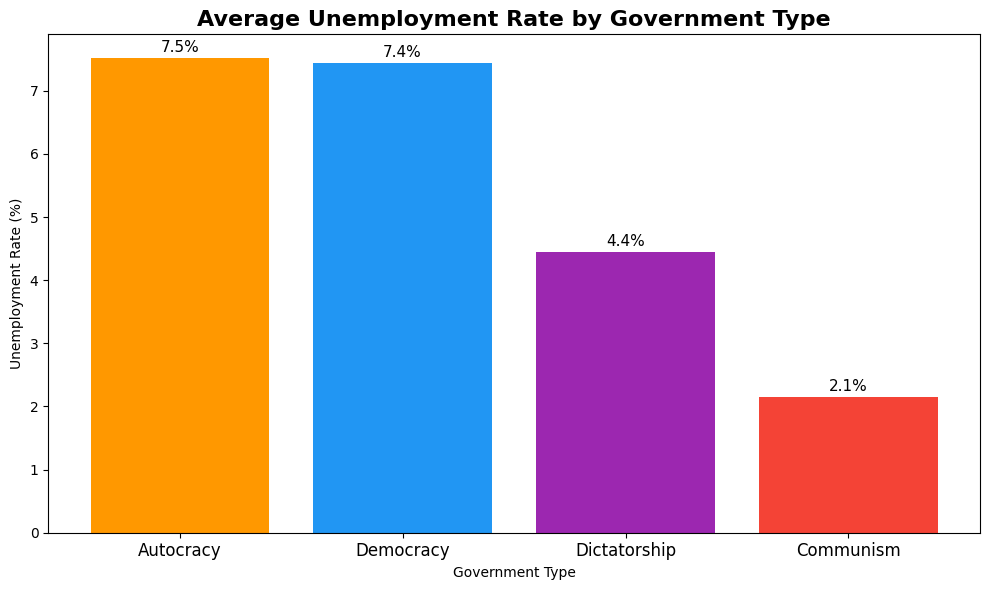

In [46]:
unemp_avg = df.groupby('Govt_Type')['Unemployment rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(unemp_avg.index, unemp_avg.values,
               color=[colors[g] for g in unemp_avg.index])

plt.title('Average Unemployment Rate by Government Type', fontsize=16, fontweight='bold')
plt.xlabel('Government Type')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


tax_avg = df.groupby('Govt_Type')['Total tax rate'].mean().sort_values(ascending=False)
bars1 = ax1.bar(tax_avg.index, tax_avg.values,
                color=[colors[g] for g in tax_avg.index])
ax1.set_title('Average Total Tax Rate', fontweight='bold')
ax1.set_ylabel('Tax Rate (%)')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center')


rev_avg = df.groupby('Govt_Type')['Tax revenue (%)'].mean().sort_values(ascending=False)
bars2 = ax2.bar(rev_avg.index, rev_avg.values,
                color=[colors[g] for g in rev_avg.index])
ax2.set_title('Average Tax Revenue (% of GDP)', fontweight='bold')
ax2.set_ylabel('Tax Revenue (%)')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


df.boxplot(column='GDP', by='Govt_Type', ax=axes[0],
           patch_artist=True)
axes[0].set_title('GDP Distribution by Govt Type', fontweight='bold')
axes[0].set_xlabel('Government Type')
axes[0].set_ylabel('GDP (USD)')


df.boxplot(column='Unemployment rate', by='Govt_Type', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Unemployment Distribution by Govt Type', fontweight='bold')
axes[1].set_xlabel('Government Type')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import f_oneway

# Separate each govt type's GDP into its own list
demo  = df[df['Govt_Type']=='Democracy']['GDP'].dropna()
auto  = df[df['Govt_Type']=='Autocracy']['GDP'].dropna()
comm  = df[df['Govt_Type']=='Communism']['GDP'].dropna()
dicta = df[df['Govt_Type']=='Dictatorship']['GDP'].dropna()

# Run ANOVA test
stat, p = f_oneway(demo, auto, comm, dicta)

print(f"ANOVA F-statistic: {stat:.2f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Result is STATISTICALLY SIGNIFICANT")
    print("→ Government type DOES impact GDP meaningfully")
else:
    print(" Result is NOT significant")
    print("Differences could be random chance")

